In [100]:
import pandas as pd

In [101]:
df = pd.read_csv('/content/employee_attrition_data.csv')

In [102]:
df

,Employee_ID,Age,Gender,Department,Job_Title,Years_at_Company,Satisfaction_Level,Average_Monthly_Hours,Promotion_Last_5Years,Salary,Attrition
0,0,27,Male,Marketing,Manager,9,0.586251,151,0,60132,0
1,1,53,Female,Sales,Engineer,10,0.261161,221,1,79947,0
2,2,59,Female,Marketing,Analyst,8,0.304382,184,0,46958,1
3,3,42,Female,Engineering,Manager,1,0.480779,242,0,40662,0
4,4,44,Female,Sales,Engineer,10,0.636244,229,1,74307,0
...,...,...,...,...,...,...,...,...,...,...,...
995,995,39,Female,HR,HR Specialist,3,0.377435,239,0,71403,0
996,996,50,Male,Engineering,Manager,1,0.431152,154,0,30181,1
997,997,52,Male,Engineering,Analyst,3,0.647102,206,0,64143,0
998,998,37,Female,HR,HR Specialist,2,0.304813,241,0,74383,1


In [103]:
#Kiểm tra dữ liệu bị thiếu
df.isna().sum()

,0
Employee_ID,0
Age,0
Gender,0
Department,0
Job_Title,0
Years_at_Company,0
Satisfaction_Level,0
Average_Monthly_Hours,0
Promotion_Last_5Years,0
Salary,0


In [104]:
#Kiểm tra dữ liệu bị lặp
duplicates = df.duplicated().sum()
print(f'Số lượng dữ liệu bị lặp: {duplicates}')

Số lượng dữ liệu bị lặp: 0


In [105]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Employee_ID,1000.0,499.500000,288.819436,0.000000,249.750000,499.500000,749.250000,999.000000
Age,1000.0,42.205000,10.016452,25.000000,33.000000,43.000000,51.000000,59.000000
Years_at_Company,1000.0,5.605000,2.822223,1.000000,3.000000,6.000000,8.000000,10.000000
Satisfaction_Level,1000.0,0.505995,0.289797,0.001376,0.258866,0.505675,0.761135,0.999979
Average_Monthly_Hours,1000.0,199.493000,29.631908,150.000000,173.000000,201.000000,225.000000,249.000000
Promotion_Last_5Years,1000.0,0.486000,0.500054,0.000000,0.000000,0.000000,1.000000,1.000000
Salary,1000.0,64624.980000,20262.984333,30099.000000,47613.500000,64525.000000,81921.000000,99991.000000
Attrition,1000.0,0.495000,0.500225,0.000000,0.000000,0.000000,1.000000,1.000000


In [106]:
#Thống kê mô tả cho các biến phân loại
df.describe(include='O')

,Gender,Department,Job_Title
count,1000,1000,1000
unique,2,5,5
top,Male,Sales,Engineer
freq,506,209,214


In [107]:
#Thống kê số phòng ban
departments = list(df['Department'].unique())
for department in departments:
    print(department)

Marketing
Sales
Engineering
Finance
HR


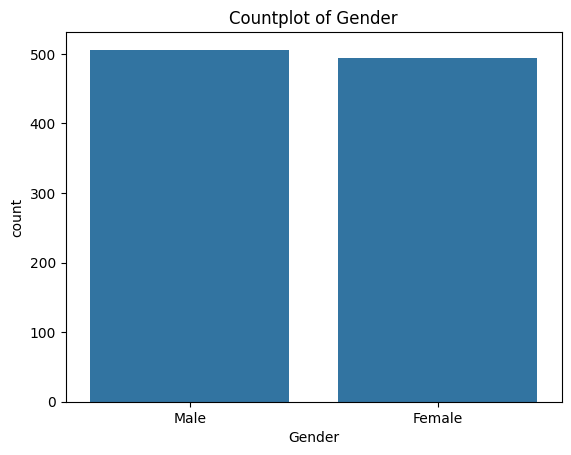

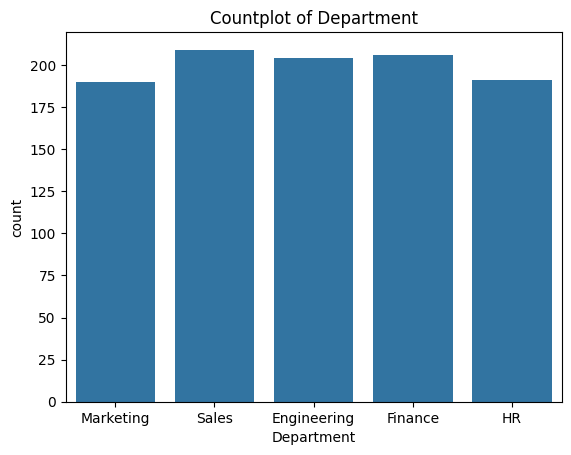

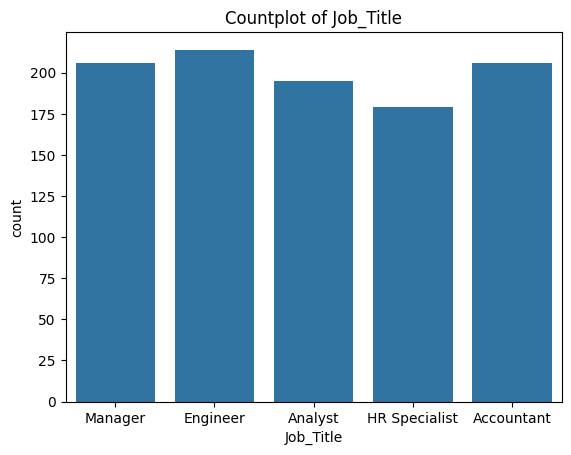

In [108]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#Thống kê số lượng nhân viên nam, nữ; số lượng nhân viên từng phòng ban; số lượng nhân viên từng chức danh
countplots = ['Gender', 'Department', 'Job_Title']
for plot in countplots:
    sns.countplot(df, x=plot)
    plt.title(f'Countplot of {plot}')
    plt.show()

<Axes: xlabel='Years_at_Company', ylabel='Age'>

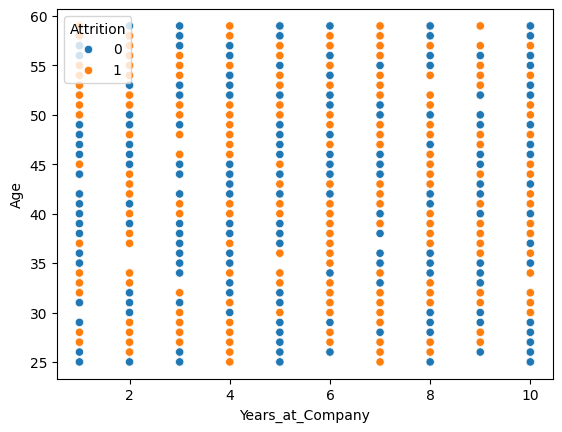

In [109]:
# Thống kê Số năm làm việc tại công ty (Years at Company) và Tuổi (Age) theo Nghỉ việc (Attrition)
sns.scatterplot(df, x='Years_at_Company', y='Age', hue='Attrition')

<Axes: xlabel='Age', ylabel='Salary'>

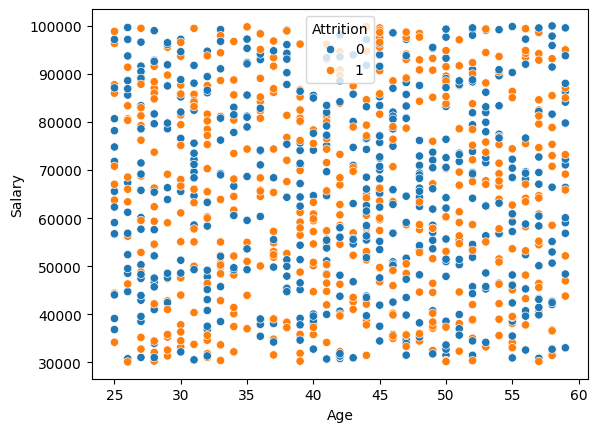

In [110]:
# Thống kê Lương (Salary) và Tuổi (Age) theo Nghỉ việc (Attrition)
sns.scatterplot(df, x='Age', y='Salary', hue='Attrition')

<Axes: xlabel='Gender'>

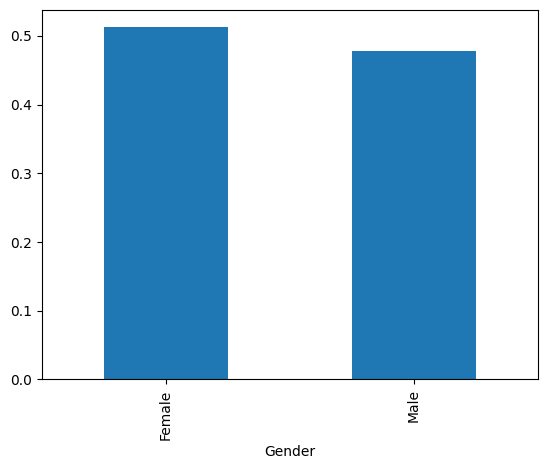

In [111]:
# Thống kê số lượng nhân viên nghỉ việc theo giới tính
attrition_by_gender = df.groupby('Gender')['Attrition'].mean()
attrition_by_gender.plot(kind='bar')

<Axes: xlabel='Department'>

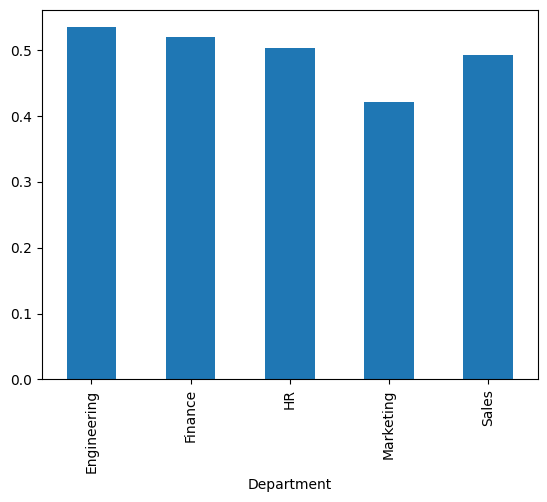

In [112]:
# Thống kê số lượng nhân viên nghỉ việc theo phòng ban
attrition_by_department = df.groupby('Department')['Attrition'].mean()
attrition_by_department.plot(kind='bar')

<Axes: xlabel='Job_Title'>

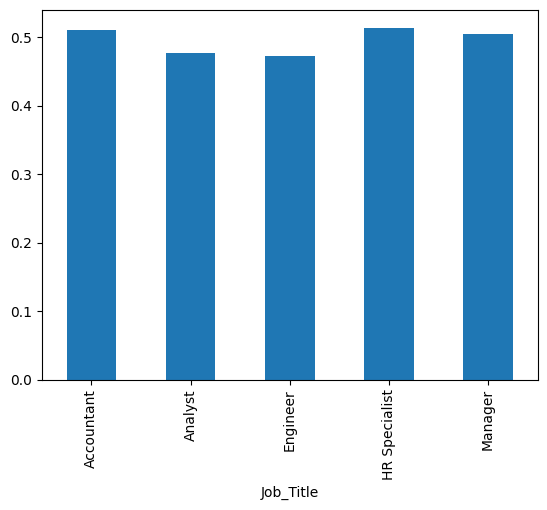

In [113]:
# Thống kê số lượng nhân viên nghỉ việc theo chức danh
attrition_by_title = df.groupby('Job_Title')['Attrition'].mean()
attrition_by_title.plot(kind='bar')

<Axes: xlabel='Promotion_Last_5Years'>

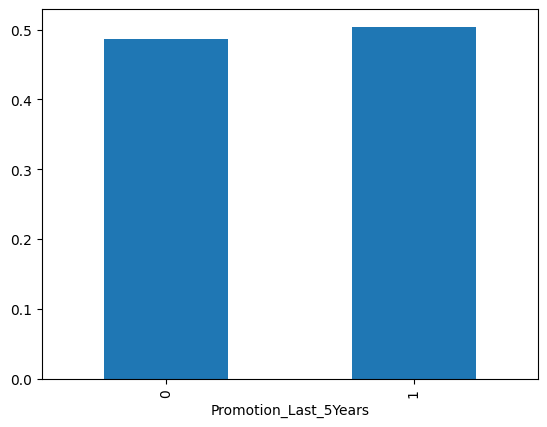

In [114]:
# Thống kê số lượng nhân viên nghỉ việc theo việc có được thăng chức trong 5 năm qua hay không
attrition_by_promotion = df.groupby('Promotion_Last_5Years')['Attrition'].mean()
attrition_by_promotion.plot(kind='bar')

In [115]:
# Tạo cột Role_ID bằng cách lấy 2 chữ cái đầu từ Department và Job_Title
df['Role_ID'] = df['Department'].str[:2] + df['Job_Title'].str[:2]

In [116]:
#Tạo cột Salary_Bracket
labels = ['Low', 'Middle', 'High', 'Very High']
df['Salary_Bracket'] = pd.qcut(df['Salary'], q=4, labels=labels)

In [117]:
#Tạo cột Overworked
labels = ['No', 'Yes']
df['Overworked'] = pd.qcut(df['Average_Monthly_Hours'], q=2, labels=labels)

<ipython-input-118-eec8016b0054>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_salary = df.groupby('Salary_Bracket')['Attrition'].mean()


<Axes: xlabel='Salary_Bracket'>

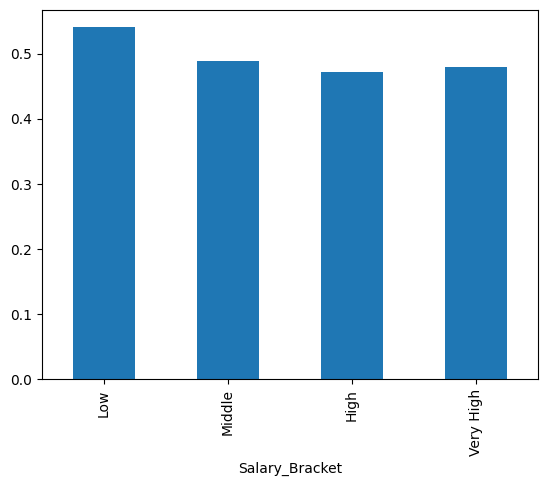

In [118]:
# Thống kê số nhân viên nghỉ việc theo Salary Bracket
attrition_by_salary = df.groupby('Salary_Bracket')['Attrition'].mean()
attrition_by_salary.plot(kind='bar')

<ipython-input-119-0a753654a76e>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_workhrs = df.groupby('Overworked')['Attrition'].mean()


<Axes: xlabel='Overworked'>

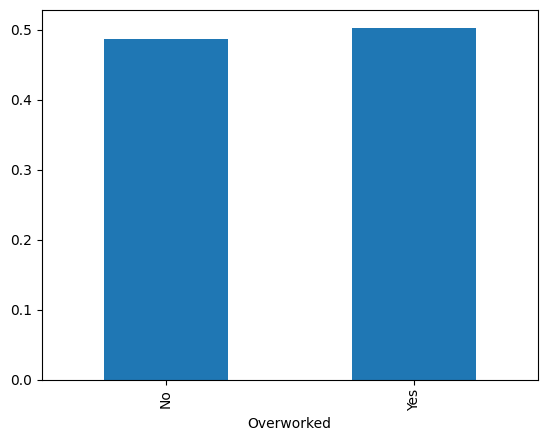

In [119]:
# Thống kê số nhân viên nghỉ việc theo Overworked
attrition_by_workhrs = df.groupby('Overworked')['Attrition'].mean()
attrition_by_workhrs.plot(kind='bar')

In [ ]:
!jupyter nbconvert --to html "/content/BTTH3_IV7.ipynb"